In [60]:
import pandas as pd
import numpy as np

df = pd.read_csv("fraud_model_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 40)


,MONTHS_AS_CUSTOMER,AGE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTIBLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_SEX,INSURED_EDUCATION_LEVEL,INSURED_OCCUPATION,...,VEHICLE_CLAIM,CLAIM_TO_PREMIUM_RATIO,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,VEHICLE_AGE,INCIDENT_YEAR,INCIDENT_MONTH,SEVERITY_SCORE,FRAUD_FLAG
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,52080,50.90,Saab,92x,2004,11,2015,1,3,1
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,3510,4.23,Mercedes,E400,2007,8,2015,1,1,1
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,23100,24.52,Dodge,RAM,2007,8,2015,2,1,0
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,50720,44.78,Chevrolet,Tahoe,2014,1,2015,1,3,1
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,4550,4.10,Accura,RSX,2009,6,2015,2,1,0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   MONTHS_AS_CUSTOMER           1000 non-null   int64  
 1   AGE                          1000 non-null   int64  
 2   POLICY_STATE                 1000 non-null   object 
 3   POLICY_CSL                   1000 non-null   object 
 4   POLICY_DEDUCTIBLE            1000 non-null   int64  
 5   POLICY_ANNUAL_PREMIUM        1000 non-null   float64
 6   UMBRELLA_LIMIT               1000 non-null   int64  
 7   INSURED_SEX                  1000 non-null   object 
 8   INSURED_EDUCATION_LEVEL      1000 non-null   object 
 9   INSURED_OCCUPATION           1000 non-null   object 
 10  INSURED_RELATIONSHIP         1000 non-null   object 
 11  POLICY_TENURE_MONTHS         1000 non-null   int64  
 12  POLICY_BIND_YEAR             1000 non-null   int64  
 13  INCIDENT_TYPE      

In [62]:
df["FRAUD_FLAG"].value_counts()

,count
FRAUD_FLAG,
0,753
1,247


In [63]:
df.shape

(1000, 40)

In [64]:
X = df.drop(
    [
        "FRAUD_FLAG",
        "SEVERITY_SCORE",
        "CALCULATED_CLAIM_TOTAL"
    ],
    axis=1,
    errors="ignore"
)

y = df["FRAUD_FLAG"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1000, 38)
Target: (1000,)


In [65]:
print(X.columns.tolist())

['MONTHS_AS_CUSTOMER', 'AGE', 'POLICY_STATE', 'POLICY_CSL', 'POLICY_DEDUCTIBLE', 'POLICY_ANNUAL_PREMIUM', 'UMBRELLA_LIMIT', 'INSURED_SEX', 'INSURED_EDUCATION_LEVEL', 'INSURED_OCCUPATION', 'INSURED_RELATIONSHIP', 'POLICY_TENURE_MONTHS', 'POLICY_BIND_YEAR', 'INCIDENT_TYPE', 'COLLISION_TYPE', 'INCIDENT_SEVERITY', 'AUTHORITIES_CONTACTED', 'INCIDENT_STATE', 'INCIDENT_CITY', 'INCIDENT_HOUR_OF_THE_DAY', 'NUMBER_OF_VEHICLES_INVOLVED', 'PROPERTY_DAMAGE', 'BODILY_INJURIES', 'WITNESSES', 'POLICE_REPORT_AVAILABLE', 'CAPITAL_GAINS', 'CAPITAL_LOSS', 'TOTAL_CLAIM_AMOUNT', 'INJURY_CLAIM', 'PROPERTY_CLAIM', 'VEHICLE_CLAIM', 'CLAIM_TO_PREMIUM_RATIO', 'AUTO_MAKE', 'AUTO_MODEL', 'AUTO_YEAR', 'VEHICLE_AGE', 'INCIDENT_YEAR', 'INCIDENT_MONTH']


In [66]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['POLICY_STATE', 'POLICY_CSL', 'INSURED_SEX', 'INSURED_EDUCATION_LEVEL', 'INSURED_OCCUPATION', 'INSURED_RELATIONSHIP', 'INCIDENT_TYPE', 'COLLISION_TYPE', 'INCIDENT_SEVERITY', 'AUTHORITIES_CONTACTED', 'INCIDENT_STATE', 'INCIDENT_CITY', 'PROPERTY_DAMAGE', 'POLICE_REPORT_AVAILABLE', 'AUTO_MAKE', 'AUTO_MODEL']

Numerical features:
['MONTHS_AS_CUSTOMER', 'AGE', 'POLICY_DEDUCTIBLE', 'POLICY_ANNUAL_PREMIUM', 'UMBRELLA_LIMIT', 'POLICY_TENURE_MONTHS', 'POLICY_BIND_YEAR', 'INCIDENT_HOUR_OF_THE_DAY', 'NUMBER_OF_VEHICLES_INVOLVED', 'BODILY_INJURIES', 'WITNESSES', 'CAPITAL_GAINS', 'CAPITAL_LOSS', 'TOTAL_CLAIM_AMOUNT', 'INJURY_CLAIM', 'PROPERTY_CLAIM', 'VEHICLE_CLAIM', 'CLAIM_TO_PREMIUM_RATIO', 'AUTO_YEAR', 'VEHICLE_AGE', 'INCIDENT_YEAR', 'INCIDENT_MONTH']


In [67]:
missing = X.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
PROPERTY_DAMAGE,360
POLICE_REPORT_AVAILABLE,343
COLLISION_TYPE,178
AUTHORITIES_CONTACTED,91


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (800, 38)
Test set: (200, 38)

Training target distribution:
FRAUD_FLAG
0    602
1    198
Name: count, dtype: int64

Test target distribution:
FRAUD_FLAG
0    151
1     49
Name: count, dtype: int64


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [70]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [71]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [73]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [74]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MONTHS_AS_CUSTOMER', 'AGE',
                                                   'POLICY_DEDUCTIBLE',
                                                   'POLICY_ANNUAL_PREMIUM',
                                                   'UMBRELLA_LIMIT',
                                                   'POLICY_TENURE_MONTHS',
                                                   'POLICY_BIND_YEAR',
                                                   'INCIDENT_HOUR_OF_THE_DAY',
                                                   'NUMBER_OF_VEHICLES_INVOLVED',...
                                                  ['POLICY_STATE', 'POLICY_CSL',
                                                   'INSURED_SEX',
                                                   'INSURED_EDUCATION_LEVEL',
                                                   'INSURED_OCCUPATION',
                                                   'INSURED_RELATIONSHIP',
                                                   'INCIDENT_TYPE',
                                                   'COLLISION_TYPE',
                                                   'INCIDENT_SEVERITY',
                                                   'AUTHORITIES_CONTACTED',
                                                   'INCIDENT_STATE',
                                                   'INCIDENT_CITY',
                                                   'PROPERTY_DAMAGE',
                                                   'POLICE_REPORT_AVAILABLE',
                                                   'AUTO_MAKE',
                                                   'AUTO_MODEL'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [75]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

[[140  11]
 [ 28  21]]


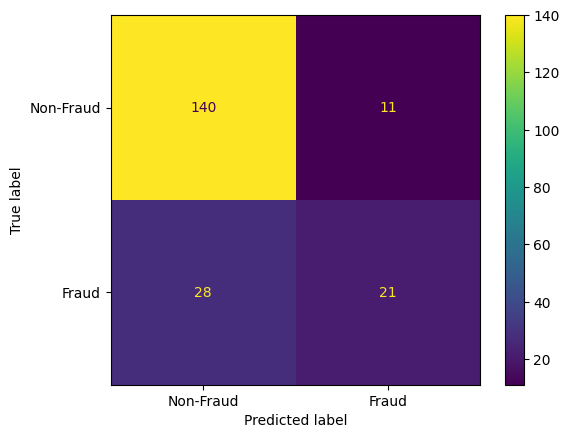

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Fraud", "Fraud"]
)

disp.plot()
plt.show()

In [77]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Non-Fraud       0.83      0.93      0.88       151
       Fraud       0.66      0.43      0.52        49

    accuracy                           0.81       200
   macro avg       0.74      0.68      0.70       200
weighted avg       0.79      0.81      0.79       200



In [78]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.7653736991485336


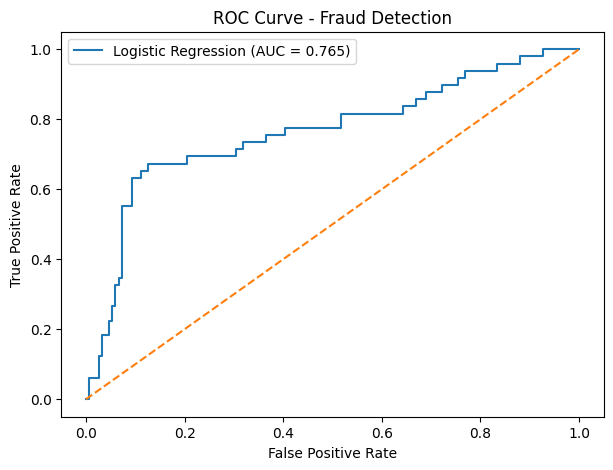

In [79]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
plt.show()

In [80]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

In [81]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MONTHS_AS_CUSTOMER', 'AGE',
                                                   'POLICY_DEDUCTIBLE',
                                                   'POLICY_ANNUAL_PREMIUM',
                                                   'UMBRELLA_LIMIT',
                                                   'POLICY_TENURE_MONTHS',
                                                   'POLICY_BIND_YEAR',
                                                   'INCIDENT_HOUR_OF_THE_DAY',
                                                   'NUMBER_OF_VEHICLES_INVOLVED',...
                                                   'INSURED_EDUCATION_LEVEL',
                                                   'INSURED_OCCUPATION',
                                                   'INSURED_RELATIONSHIP',
                                                   'INCIDENT_TYPE',
                                                   'COLLISION_TYPE',
                                                   'INCIDENT_SEVERITY',
                                                   'AUTHORITIES_CONTACTED',
                                                   'INCIDENT_STATE',
                                                   'INCIDENT_CITY',
                                                   'PROPERTY_DAMAGE',
                                                   'POLICE_REPORT_AVAILABLE',
                                                   'AUTO_MAKE',
                                                   'AUTO_MODEL'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [82]:
rf_pred = random_forest_model.predict(X_test)

rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [83]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["Non-Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Non-Fraud       0.82      0.93      0.87       151
       Fraud       0.63      0.39      0.48        49

    accuracy                           0.80       200
   macro avg       0.73      0.66      0.68       200
weighted avg       0.78      0.80      0.78       200



In [84]:
from sklearn.metrics import roc_auc_score

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.7920664954723612


In [85]:
from sklearn.metrics import classification_report

threshold = 0.40

rf_pred_040 = (rf_prob >= threshold).astype(int)

print(classification_report(
    y_test,
    rf_pred_040,
    target_names=["Non-Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Non-Fraud       0.88      0.88      0.88       151
       Fraud       0.62      0.61      0.62        49

    accuracy                           0.81       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.81      0.81      0.81       200



In [86]:
threshold = 0.30

rf_pred_030 = (rf_prob >= threshold).astype(int)

print(classification_report(
    y_test,
    rf_pred_030,
    target_names=["Non-Fraud", "Fraud"]
))

              precision    recall  f1-score   support

   Non-Fraud       0.91      0.83      0.87       151
       Fraud       0.59      0.73      0.65        49

    accuracy                           0.81       200
   macro avg       0.75      0.78      0.76       200
weighted avg       0.83      0.81      0.82       200



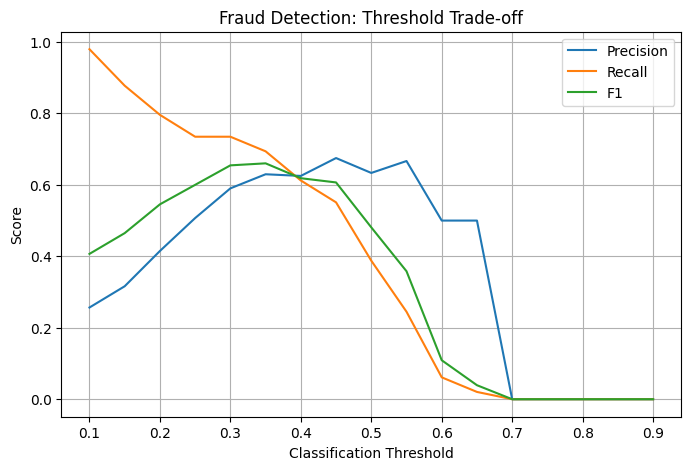

In [87]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.10, 0.91, 0.05)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    predictions = (rf_prob >= threshold).astype(int)

    precision_scores.append(
        precision_score(y_test, predictions, zero_division=0)
    )

    recall_scores.append(
        recall_score(y_test, predictions, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_test, predictions, zero_division=0)
    )

plt.figure(figsize=(8, 5))

plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, recall_scores, label="Recall")
plt.plot(thresholds, f1_scores, label="F1")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Fraud Detection: Threshold Trade-off")
plt.legend()
plt.grid(True)
plt.show()

In [88]:
# Get the trained preprocessing step
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

# Get the trained Random Forest
rf_classifier = random_forest_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance
importances = rf_classifier.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
64,cat__INCIDENT_SEVERITY_Major Damage,0.120532
16,num__VEHICLE_CLAIM,0.039402
15,num__PROPERTY_CLAIM,0.038262
17,num__CLAIM_TO_PREMIUM_RATIO,0.036758
65,cat__INCIDENT_SEVERITY_Minor Damage,0.035696
13,num__TOTAL_CLAIM_AMOUNT,0.033868
0,num__MONTHS_AS_CUSTOMER,0.031337
3,num__POLICY_ANNUAL_PREMIUM,0.030436
5,num__POLICY_TENURE_MONTHS,0.030044
14,num__INJURY_CLAIM,0.027899


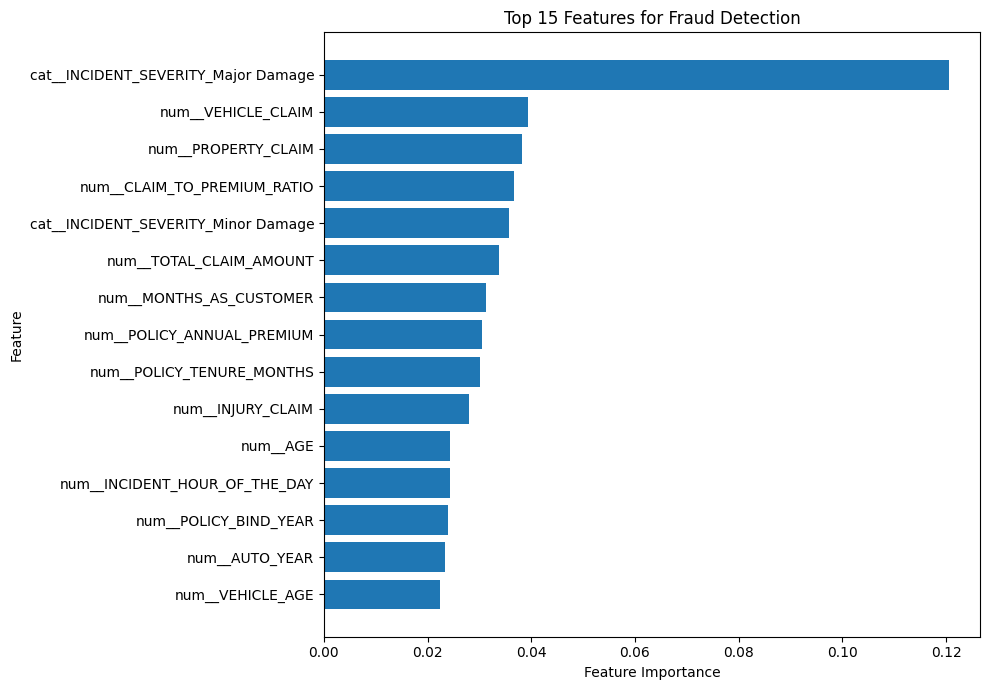

In [89]:
top_features = feature_importance.head(15).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Fraud Detection")

plt.tight_layout()
plt.show()

In [90]:
def assign_risk_level(probability):
    if probability >= 0.60:
        return "High Risk"
    elif probability >= 0.30:
        return "Medium Risk"
    else:
        return "Low Risk"

In [91]:
results = X_test.copy()

results["actual_fraud"] = y_test.values
results["fraud_probability"] = rf_prob
results["predicted_fraud"] = rf_pred_030

results["risk_level"] = results["fraud_probability"].apply(
    assign_risk_level
)

results.head()

,MONTHS_AS_CUSTOMER,AGE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTIBLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_SEX,INSURED_EDUCATION_LEVEL,INSURED_OCCUPATION,...,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,VEHICLE_AGE,INCIDENT_YEAR,INCIDENT_MONTH,actual_fraud,fraud_probability,predicted_fraud,risk_level
908,285,44,OH,250/500,2000,1144.30,0,MALE,MD,priv-house-serv,...,Honda,Civic,2010,5,2015,2,0,0.130000,0,Low Risk
973,230,37,IL,500/1000,1000,1060.74,0,MALE,PhD,tech-support,...,Suburu,Impreza,1996,19,2015,1,1,0.466667,1,Medium Risk
154,101,33,OH,100/300,1000,1053.04,7000000,FEMALE,Masters,other-service,...,Saab,93,2013,2,2015,2,1,0.196667,0,Low Risk
977,266,42,IN,100/300,500,1093.83,4000000,MALE,Associate,adm-clerical,...,Suburu,Impreza,2015,0,2015,2,1,0.503333,1,Medium Risk
50,430,59,OH,250/500,2000,1326.62,7000000,MALE,MD,other-service,...,Nissan,Pathfinder,1998,17,2015,1,0,0.146667,0,Low Risk


In [92]:
results[
    [
        "fraud_probability",
        "predicted_fraud",
        "risk_level",
        "actual_fraud"
    ]
].sort_values(
    "fraud_probability",
    ascending=False
).head(20)

,fraud_probability,predicted_fraud,risk_level,actual_fraud
669,0.696667,1,High Risk,0
710,0.660000,1,High Risk,1
128,0.650000,1,High Risk,1
661,0.620000,1,High Risk,0
261,0.616667,1,High Risk,1
540,0.610000,1,High Risk,0
56,0.596667,1,Medium Risk,0
283,0.590000,1,Medium Risk,1
251,0.586667,1,Medium Risk,1
245,0.583333,1,Medium Risk,1


In [93]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "models/fraud_random_forest.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [94]:
results.to_csv(
    "fraud_predictions.csv",
    index=False
)

print("Predictions saved:", results.shape)

Predictions saved: (200, 42)
